In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


Dataset Shape: (303, 14)

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-nul

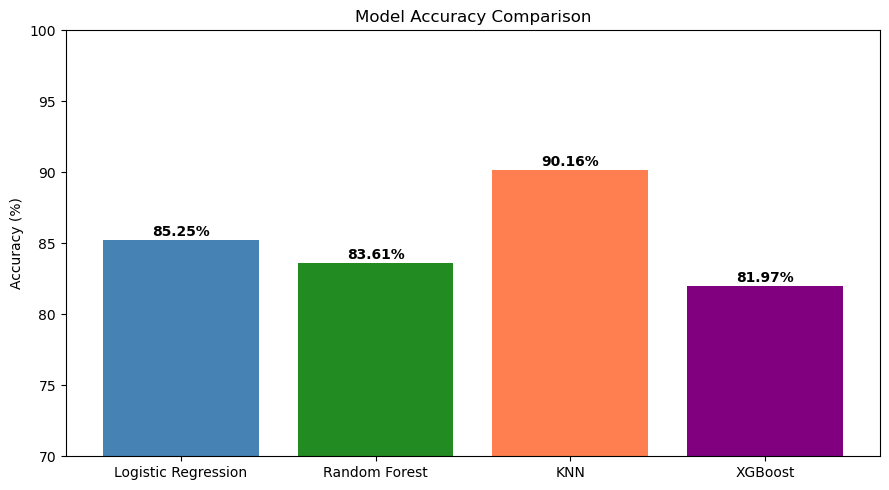

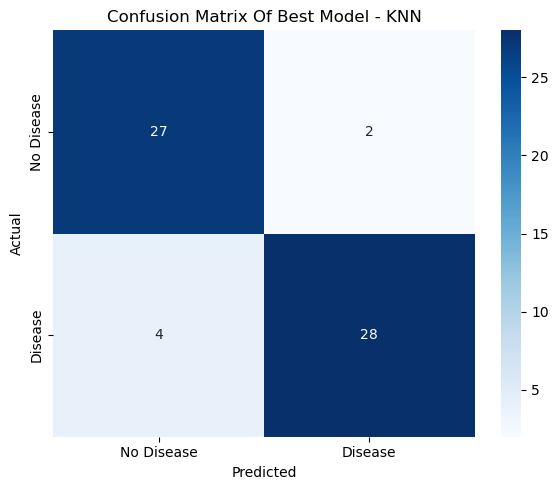

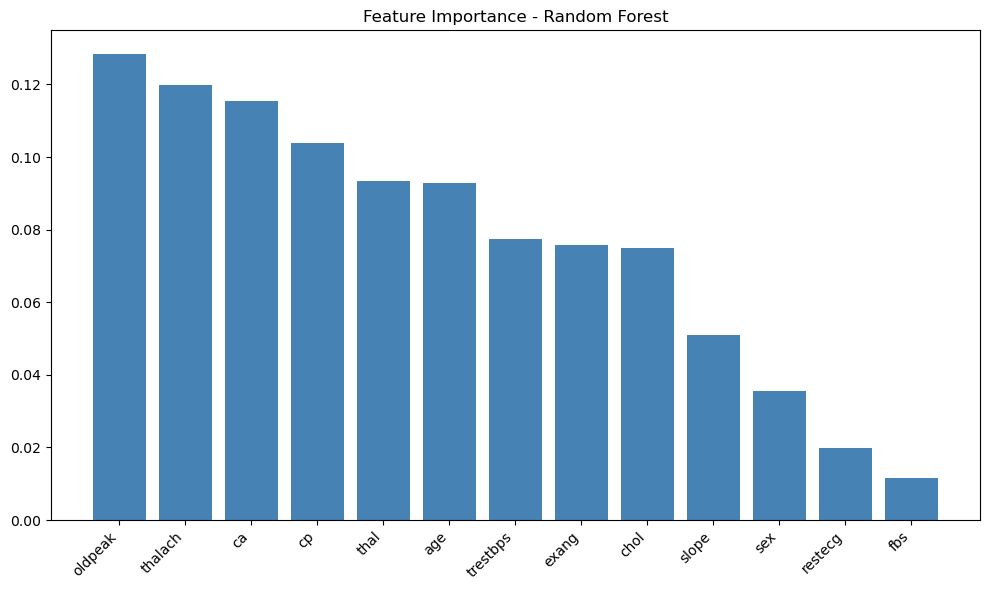

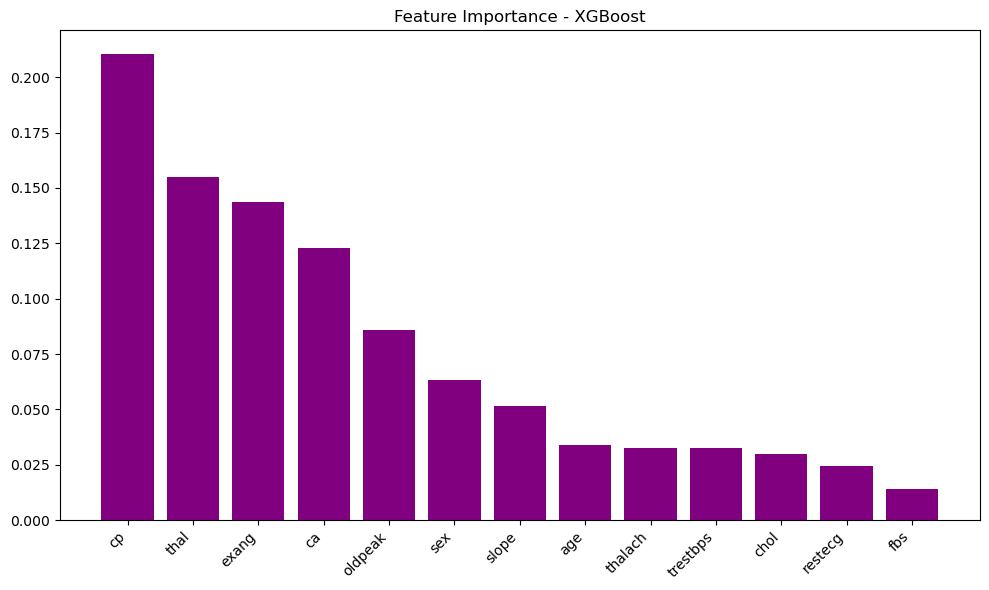

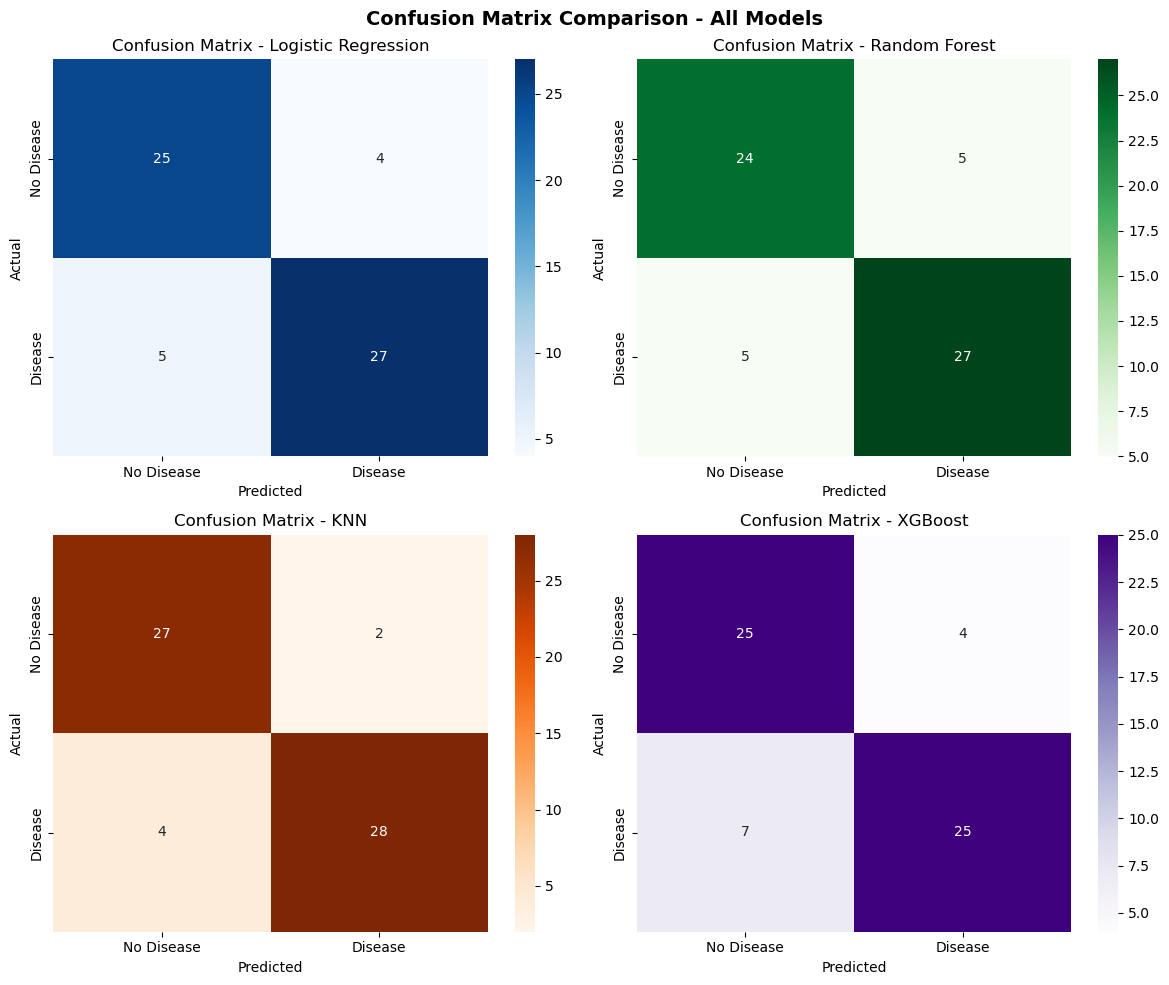

In [4]:
# Heart Disease Prediction Using Machine Learning
# Dataset: UCI Heart Disease Dataset

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────
#CSV
df = pd.read_csv("heart.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# ─────────────────────────────
# 2. DATA PREPROCESSING
# ─────────────────────────────
# Target column: 'target' (1 = Heart Disease, 0 = No Heart Disease)
X = df.drop('target', axis=1)
y = df['target']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# ─────────────────────────────
# 3. TRAIN MODELS
# ─────────────────────────────

# Model 1: Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Model 3: K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

# Model 4: XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

# ─────────────────────────────
# 4. RESULTS
# ─────────────────────────────
print("\n" + "="*40)
print("MODEL ACCURACY COMPARISON")
print("="*40)
print(f"Logistic Regression : {lr_acc*100:.2f}%")
print(f"Random Forest       : {rf_acc*100:.2f}%")
print(f"K-Nearest Neighbors : {knn_acc*100:.2f}%")
print(f"XGBoost             : {xgb_acc*100:.2f}%")

# Find Best Model
accuracies_dict = {
    "Logistic Regression": lr_acc,
    "Random Forest": rf_acc,
    "KNN": knn_acc,
    "XGBoost": xgb_acc
}

best_model_name = max(accuracies_dict, key=accuracies_dict.get)

# Get Predictions of Best Model
if best_model_name == "Logistic Regression":
    best_pred = lr_pred
elif best_model_name == "Random Forest":
    best_pred = rf_pred
elif best_model_name == "KNN":
    best_pred = knn_pred
else:
    best_pred = xgb_pred

print(f"\nTHE BEST MODEL IS: {best_model_name}")
print("\nClassification Report:")
print(classification_report(y_test, best_pred))

# ─────────────────────────────
# 5. VISUALIZATIONS
# ─────────────────────────────

# Plot 1: Accuracy Comparison Bar Chart
models = ['Logistic Regression', 'Random Forest', 'KNN', 'XGBoost']
accuracies = [lr_acc*100, rf_acc*100, knn_acc*100, xgb_acc*100]

plt.figure(figsize=(9, 5))
plt.bar(models, accuracies, color=['steelblue', 'forestgreen', 'coral', 'purple'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(70, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_comparison.png')
plt.show()

# Plot 2: Confusion Matrix for Best Model
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix Of Best Model - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Plot 3: Feature Importance (Random Forest)
feature_names = df.drop('target', axis=1).columns
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha='right')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance_rf.png')
plt.show()

# Plot 4: Feature Importance (XGBoost)
xgb_importances = xgb.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(xgb_importances)), xgb_importances[xgb_indices], color='purple')
plt.xticks(range(len(xgb_importances)), feature_names[xgb_indices], rotation=45, ha='right')
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png')
plt.show()

# Plot 5: Confusion Matrix - All 4 Models side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
all_preds = [lr_pred, rf_pred, knn_pred, xgb_pred]
all_names = ['Logistic Regression', 'Random Forest', 'KNN', 'XGBoost']
colors    = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, pred, name, color in zip(axes.flatten(), all_preds, all_names, colors):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_all.png')
plt.show()

